In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

from data.data_utils import *  # noqa: F403

In [62]:
df = pd.read_csv('pricing_data.csv')
df.head()

,id(),SECURITY_DES,EXERCISE_TYPE,EXPIRE_DT,PUT_CALL,STRIKE_PX,TICKER,Date,OPT_PX,HIST_PUT_IMP_VOL,VOLATILITY_30D,HIST_CALL_IMP_VOL,VOLATILITY_60D,VOLATILITY_90D,VOLATILITY_10D,VOLATILITY_20D,RISK_FREE_RATE,UNDERLYING_PRICE,TIME_TO_MATURITY
0,BBG01MS5CJS3,G9F6C 76.55 Comdty,European,2026-01-30,Call,76.55,G9F6 Comdty,2024-09-11,3.21,29.77,30.13,29.77,24.94,22.90,34.63,30.34,0.03653,67.309998,1.386301
1,BBG01MS5CJS3,G9F6C 76.55 Comdty,European,2026-01-30,Call,76.55,G9F6 Comdty,2024-09-19,4.09,28.12,29.19,28.11,25.66,23.55,29.14,31.54,0.03740,71.949997,1.364384
2,BBG01MS5CJS3,G9F6C 76.55 Comdty,European,2026-01-30,Call,76.55,G9F6 Comdty,2024-09-20,4.01,27.79,29.09,27.77,25.64,23.52,29.36,30.41,0.03728,71.919998,1.361644
3,BBG01MS5CJS3,G9F6C 76.55 Comdty,European,2026-01-30,Call,76.55,G9F6 Comdty,2024-10-01,4.24,30.42,28.91,30.37,26.61,24.34,25.42,27.15,0.03743,69.830002,1.331507
4,BBG01MS5CJS3,G9F6C 76.55 Comdty,European,2026-01-30,Call,76.55,G9F6 Comdty,2024-10-02,4.41,32.30,28.66,32.28,26.62,24.33,24.38,27.15,0.03785,70.099998,1.328767


In [78]:
df.columns

Index(['id()', 'SECURITY_DES', 'EXERCISE_TYPE', 'EXPIRE_DT', 'PUT_CALL',
       'STRIKE_PX', 'TICKER', 'Date', 'OPT_PX', 'HIST_PUT_IMP_VOL',
       'VOLATILITY_30D', 'HIST_CALL_IMP_VOL', 'VOLATILITY_60D',
       'VOLATILITY_90D', 'VOLATILITY_10D', 'VOLATILITY_20D', 'RISK_FREE_RATE',
       'UNDERLYING_PRICE', 'TIME_TO_MATURITY'],
      dtype='object')

In [67]:
ticker_list = get_ticker_by_value_count(df, 75, 44)
print(ticker_list)

Selecting tickers with at least 44 occurrences.
Index(['G9F6C 75 Comdty', 'G9H6C 75 Comdty', 'G9J6C 75 Comdty',
       'G9K6C 75 Comdty', 'G9M6C 75 Comdty', 'G9G6C 75 Comdty'],
      dtype='object', name='SECURITY_DES')


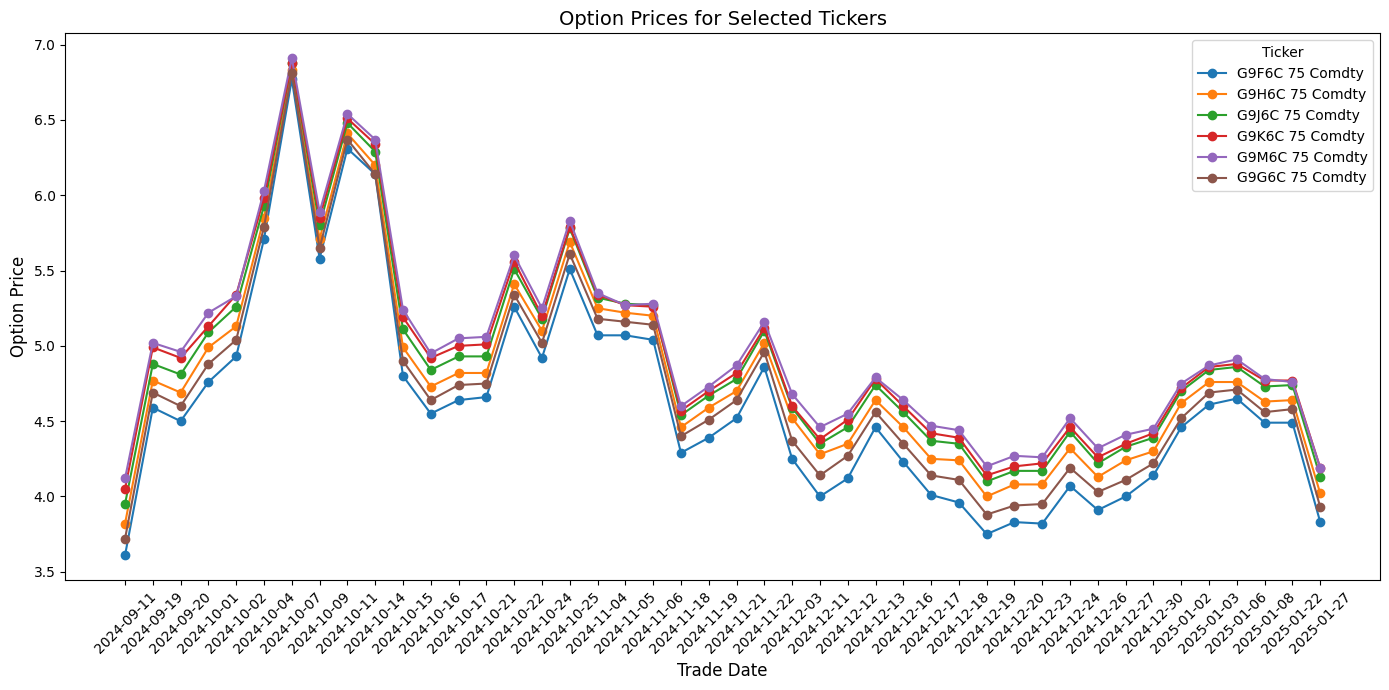

In [69]:
fig, ax = plt.subplots(figsize=(14, 7))
for ticker in ticker_list:
    tmp_df = filter_by_security_des(df, ticker)
    ax.plot(tmp_df['Date'], tmp_df['OPT_PX'], marker='o', label=ticker)
ax.set_xlabel('Trade Date', fontsize=12)
ax.set_ylabel('Option Price', fontsize=12)
ax.set_title('Option Prices for Selected Tickers', fontsize=14)
ax.legend(title='Ticker')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

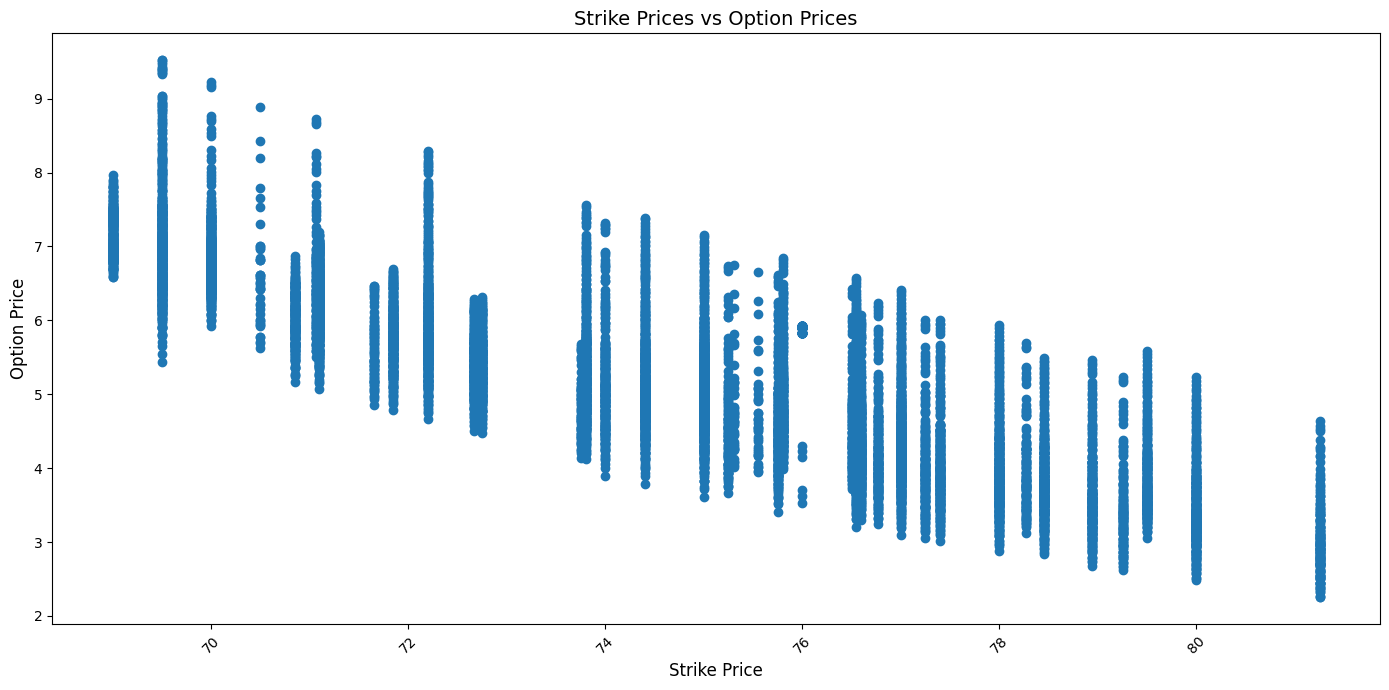

In [74]:
fig, ax = plt.subplots(figsize=(14, 7))
ax.plot(df['STRIKE_PX'], df['OPT_PX'], marker='o', linestyle='None')
ax.set_xlabel('Strike Price', fontsize=12)
ax.set_ylabel('Option Price', fontsize=12)
ax.set_title('Strike Prices vs Option Prices', fontsize=14)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

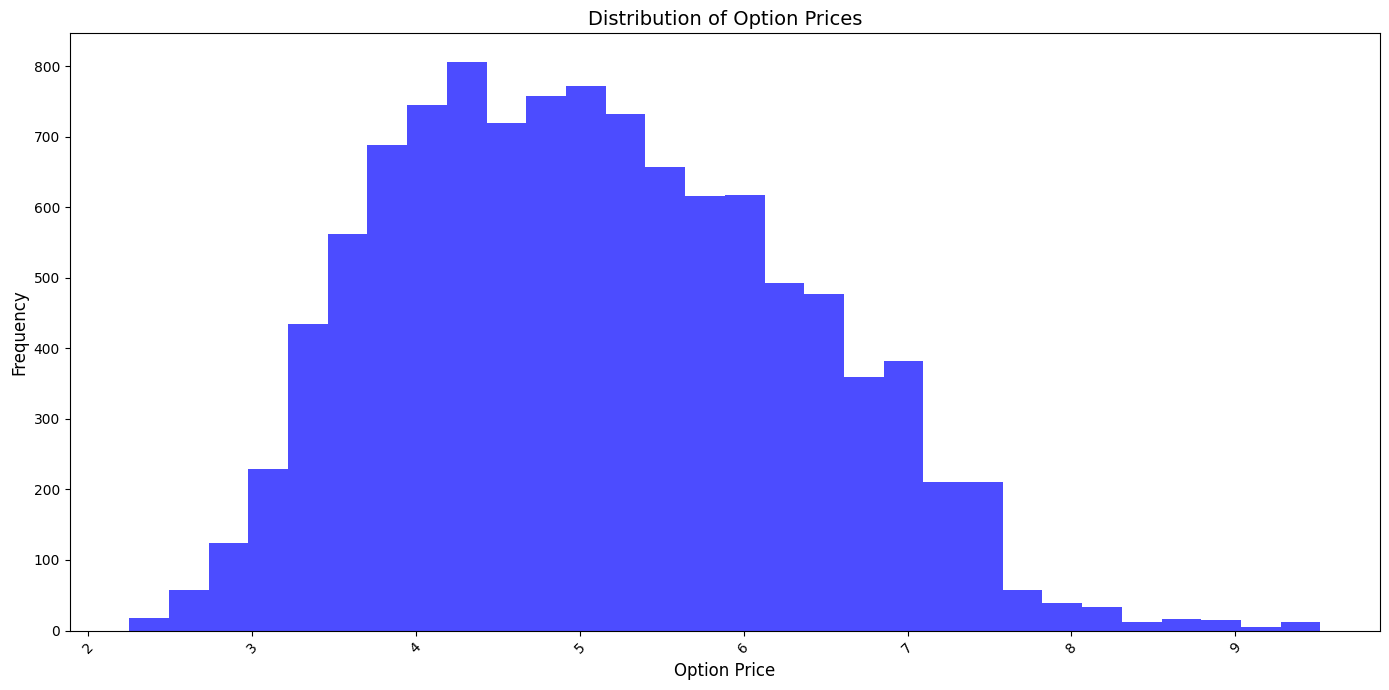

In [75]:
# Plotting the distribution of option prices
fig, ax = plt.subplots(figsize=(14, 7))
ax.hist(df['OPT_PX'], bins=30, alpha=0.7, color='blue')
ax.set_xlabel('Option Price', fontsize=12)
ax.set_ylabel('Frequency', fontsize=12)
ax.set_title('Distribution of Option Prices', fontsize=14)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

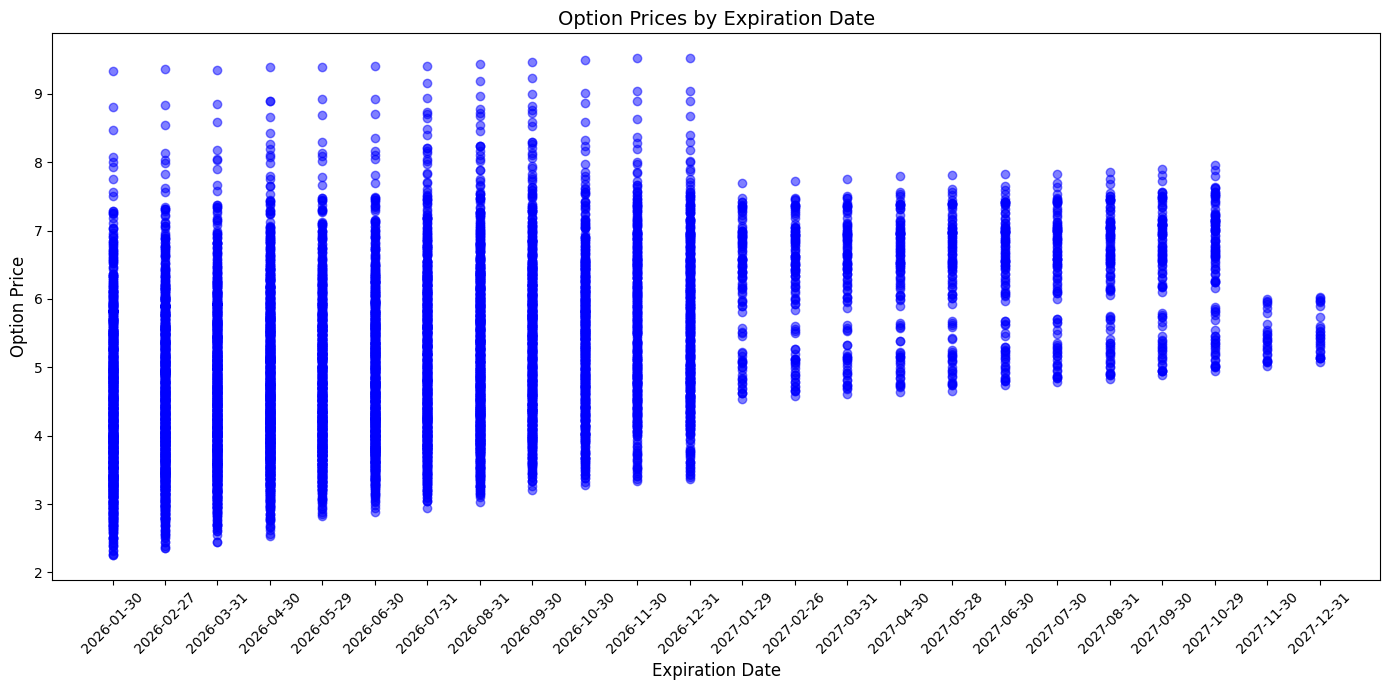

In [ ]:
# plot option prices by expiration date
fig, ax = plt.subplots(figsize=(14, 7))
ax.scatter(df['EXPIRE_DT'], df['OPT_PX'], alpha=0.5, color='blue')
ax.set_xlabel('Expiration Date', fontsize=12)
ax.set_ylabel('Option Price', fontsize=12)
ax.set_title('Option Prices by Expiration Date', fontsize=14)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()